In [122]:
# ============================================
# Imports Libs
# ============================================
import sys
from pathlib import Path

import warnings
import itertools

import numpy as np
import pandas as pd

import scipy
from scipy import stats

from sklearn import metrics
from sklearn.linear_model import LinearRegression

import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap

import seaborn as sns

from IPython.display import display

warnings.filterwarnings("ignore")

# ============================================
# Versions
# ============================================

print("python     =", sys.version.split()[0])
print("pandas     =", pd.__version__)
print("numpy      =", np.__version__)
print("scipy      =", scipy.__version__)
print("matplotlib =", mpl.__version__)
print("seaborn    =", sns.__version__)

python     = 3.11.15
pandas     = 2.3.3
numpy      = 2.4.6
scipy      = 1.17.1
matplotlib = 3.10.9
seaborn    = 0.13.2


In [123]:
# ============================================
# Global plotting configuration
# ============================================

_PLOT_CFG = {
    "fig_w": 6.0,
    "fig_h": 5.0,
    "dpi": 300,
}


def set_plot_style(
    *,
    # Fonts
    base_fontsize=11,
    title_fontsize=14,
    label_fontsize=13,
    tick_fontsize=11,
    legend_fontsize=11,

    dpi=300,

    axes_linewidth=1.2,
    spines_top=True,
    spines_right=True,

    tick_size_major=6,
    tick_dir="out",

    grid=False,

    fig_w=6.0,
    fig_h=5.0,
):

    sns.set_style("ticks")

    mpl.rcParams.update({

        # =====================================
        # Fonts
        # =====================================
        "font.family": "DejaVu Sans",
        "font.size": base_fontsize,

        "axes.titlesize": title_fontsize,
        "axes.labelsize": label_fontsize,

        "xtick.labelsize": tick_fontsize,
        "ytick.labelsize": tick_fontsize,

        "legend.fontsize": legend_fontsize,

        # =====================================
        # Figure
        # =====================================
        "figure.dpi": dpi,
        "savefig.dpi": dpi,

        # =====================================
        # Axes
        # =====================================
        "axes.linewidth": axes_linewidth,
        "axes.spines.top": spines_top,
        "axes.spines.right": spines_right,
        "axes.grid": grid,
        "axes.axisbelow": True,

        # =====================================
        # Ticks
        # =====================================
        "xtick.major.size": tick_size_major,
        "ytick.major.size": tick_size_major,
        "xtick.direction": tick_dir,
        "ytick.direction": tick_dir,

        # =====================================
        # Legend
        # =====================================
        "legend.frameon": False,

        # =====================================
        # Save figure
        # =====================================
        "savefig.bbox": "tight",
        "savefig.transparent": False,
    })

    _PLOT_CFG.update({
        "fig_w": fig_w,
        "fig_h": fig_h,
        "dpi": dpi,
    })


def make_fig(
    w=None,
    h=None,
    dpi=None,
):
    W = float(w) if w is not None else _PLOT_CFG["fig_w"]
    H = float(h) if h is not None else _PLOT_CFG["fig_h"]
    D = dpi if dpi is not None else _PLOT_CFG["dpi"]

    fig, ax = plt.subplots(
        figsize=(W, H),
        dpi=D,
    )

    return fig, ax


set_plot_style()

In [124]:
# Input directory
NFCORE_DIR = Path("/mnt/d/Ibnu/riboseq/AT/nfcore/full")

TX2GENE_FILE = NFCORE_DIR / "quantification/tx2gene.tsv"
COUNTS_FILE = NFCORE_DIR / "quantification/salmon/salmon.merged.transcript_counts.tsv"
TPM_FILE = NFCORE_DIR / "quantification/salmon/salmon.merged.transcript_tpm.tsv"

# Output directory
OUTDIR = Path("/mnt/d/Ibnu/riboseq/AT/postprocess/arabidopsis_thaliana/results")
OUTDIR.mkdir(parents=True, exist_ok=True)

In [125]:
tx2gene = pd.read_csv(TX2GENE_FILE, sep="\t")
counts = pd.read_csv(COUNTS_FILE, sep="\t")
tpm = pd.read_csv(TPM_FILE, sep="\t")

print("tx2gene:", tx2gene.shape)
print("counts:", counts.shape)
print("tpm:", tpm.shape)

tx2gene: (59478, 3)
counts: (59051, 4)
tpm: (59051, 4)


In [126]:
# Rename columns to consistent names
tx2gene = tx2gene.rename(columns={
    "transcript_id": "transcript_id",
    "gene_id": "gene_id",
    "gene_name": "gene_name",
})

counts = counts.rename(columns={
    "tx": "transcript_id",
    "RIBO_FULL": "ribo_read_count",
    "RNA_FULL": "rna_read_count",
})

tpm = tpm.rename(columns={
    "tx": "transcript_id",
    "RIBO_FULL": "ribo_tpm",
    "RNA_FULL": "rna_tpm",
})

# Keep only needed columns
counts = counts[["transcript_id", "gene_id", "ribo_read_count", "rna_read_count"]]
tpm = tpm[["transcript_id", "gene_id", "ribo_tpm", "rna_tpm"]]

display(tx2gene.head())
display(counts.head())
display(tpm.head())

,transcript_id,gene_id,gene_name
0,AT1G01010.1,AT1G01010,AT1G01010
1,AT1G01020.2,AT1G01020,AT1G01020
2,AT1G01020.6,AT1G01020,AT1G01020
3,AT1G01020.1,AT1G01020,AT1G01020
4,AT1G01020.3,AT1G01020,AT1G01020


,transcript_id,gene_id,ribo_read_count,rna_read_count
0,AT1G01010.1,AT1G01010,24.0,157.000
1,AT1G01020.2,AT1G01020,14.0,211.134
2,AT1G01020.6,AT1G01020,0.0,12.734
3,AT1G01020.1,AT1G01020,0.0,347.194
4,AT1G01020.3,AT1G01020,0.0,47.368


,transcript_id,gene_id,ribo_tpm,rna_tpm
0,AT1G01010.1,AT1G01010,0.107730,2.876792
1,AT1G01020.2,AT1G01020,0.107966,6.646622
2,AT1G01020.6,AT1G01020,0.000000,0.483483
3,AT1G01020.1,AT1G01020,0.000000,8.478478
4,AT1G01020.3,AT1G01020,0.000000,1.066754


In [127]:
master = (
    tx2gene
    .merge(
        counts,
        on=["transcript_id", "gene_id"],
        how="left",
    )
    .merge(
        tpm,
        on=["transcript_id", "gene_id"],
        how="left",
    )
)

print(master.shape)
display(master.head())

(59478, 7)


,transcript_id,gene_id,gene_name,ribo_read_count,rna_read_count,ribo_tpm,rna_tpm
0,AT1G01010.1,AT1G01010,AT1G01010,24.0,157.000,0.107730,2.876792
1,AT1G01020.2,AT1G01020,AT1G01020,14.0,211.134,0.107966,6.646622
2,AT1G01020.6,AT1G01020,AT1G01020,0.0,12.734,0.000000,0.483483
3,AT1G01020.1,AT1G01020,AT1G01020,0.0,347.194,0.000000,8.478478
4,AT1G01020.3,AT1G01020,AT1G01020,0.0,47.368,0.000000,1.066754


In [128]:
master = (
    tx2gene
    .merge(
        counts,
        on=["transcript_id", "gene_id"],
        how="left",
    )
    .merge(
        tpm,
        on=["transcript_id", "gene_id"],
        how="left",
    )
)

# Keep only transcripts with complete quantification
# and sufficient read support in both datasets
master = master.loc[
    master[
        [
            "ribo_read_count",
            "rna_read_count",
            "ribo_tpm",
            "rna_tpm",
        ]
    ].notna().all(axis=1)
    &
    (master["ribo_read_count"] > 0)
    &
    (master["rna_read_count"] > 0)
].copy()

print(master.shape)
display(master.head())

(22306, 7)


,transcript_id,gene_id,gene_name,ribo_read_count,rna_read_count,ribo_tpm,rna_tpm
0,AT1G01010.1,AT1G01010,AT1G01010,24.00,157.000,0.107730,2.876792
1,AT1G01020.2,AT1G01020,AT1G01020,14.00,211.134,0.107966,6.646622
9,AT1G01030.2,AT1G01030,AT1G01030,7.00,19.582,0.028489,0.325320
10,AT1G01040.1,AT1G01040,AT1G01040,48.00,2345.008,0.051416,10.253755
15,AT1G01050.1,AT1G01050,AT1G01050,197.02,2517.218,1.709312,89.148807


In [129]:
# ============================================
# CLR-based residual TE
# ============================================

master["rna_clr"] = (
    np.log(master["rna_read_count"])
    - np.log(master["rna_read_count"]).mean()
)

master["ribo_clr"] = (
    np.log(master["ribo_read_count"])
    - np.log(master["ribo_read_count"]).mean()
)

x = master[["rna_clr"]]
y = master["ribo_clr"]

model = LinearRegression()
model.fit(x, y)

master["TE"] = y - model.predict(x)

print("Regression intercept:", model.intercept_)
print("Regression slope:", model.coef_[0])

display(master[[
    "transcript_id",
    "gene_id",
    "rna_read_count",
    "ribo_read_count",
    "ribo_tpm",
    "rna_tpm",
    "rna_clr",
    "ribo_clr",
    "TE",
]].head())

Regression intercept: 3.535782132548942e-16
Regression slope: 0.674890395355233


,transcript_id,gene_id,rna_read_count,ribo_read_count,ribo_tpm,rna_tpm,rna_clr,ribo_clr,TE
0,AT1G01010.1,AT1G01010,157.000,24.00,0.107730,2.876792,-0.930637,-0.390050,0.238028
1,AT1G01020.2,AT1G01020,211.134,14.00,0.107966,6.646622,-0.634390,-0.929047,-0.500903
9,AT1G01030.2,AT1G01030,19.582,7.00,0.028489,0.325320,-3.012272,-1.622194,0.410760
10,AT1G01040.1,AT1G01040,2345.008,48.00,0.051416,10.253755,1.773161,0.303097,-0.893593
15,AT1G01050.1,AT1G01050,2517.218,197.02,1.709312,89.148807,1.844027,1.715201,0.470685


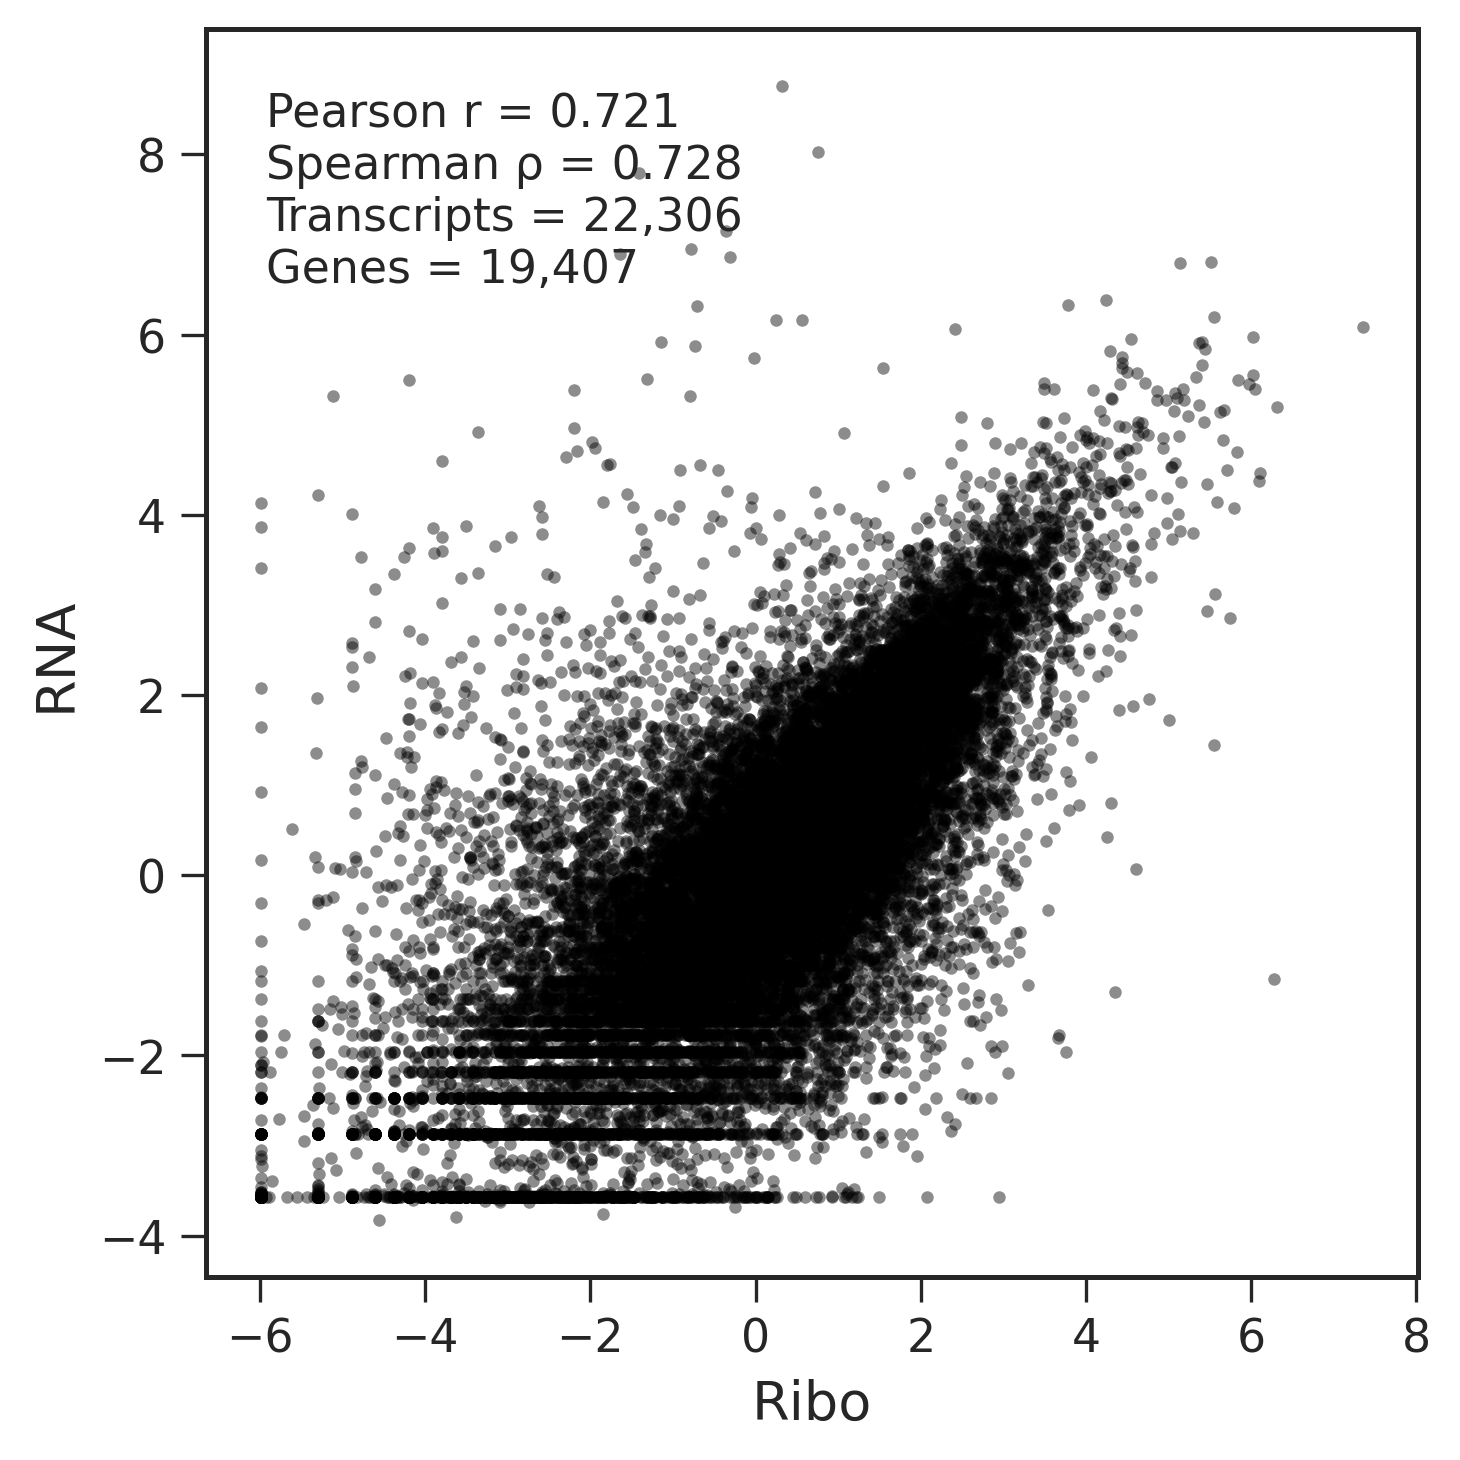

In [130]:
from scipy.stats import spearmanr, pearsonr

# ============================================
# Ribo-seq TPM vs RNA-seq TPM
# ============================================

x = master["rna_clr"]
y = master["ribo_clr"]

spearman_r, spearman_p = spearmanr(x, y)
pearson_r, pearson_p = pearsonr(x, y)

n_transcripts = master["transcript_id"].nunique()
n_genes = master["gene_id"].nunique()

fig, ax = make_fig(w =5, h= 5)

ax.scatter(
    x,
    y,
    s=9,
    color="black",
    alpha=0.45,
    linewidths=0,
)

# ax.set_title("Ribo-seq TPM vs RNA-seq TPM")
ax.set_xlabel("Ribo")
ax.set_ylabel("RNA")

text = (
    f"Pearson r = {pearson_r:.3f}\n"
    f"Spearman ρ = {spearman_r:.3f}\n"
    f"Transcripts = {n_transcripts:,}\n"
    f"Genes = {n_genes:,}\n"
)

ax.text(
    0.05,
    0.95,
    text,
    transform=ax.transAxes,
    ha="left",
    va="top",
)

plt.tight_layout()
plt.show()

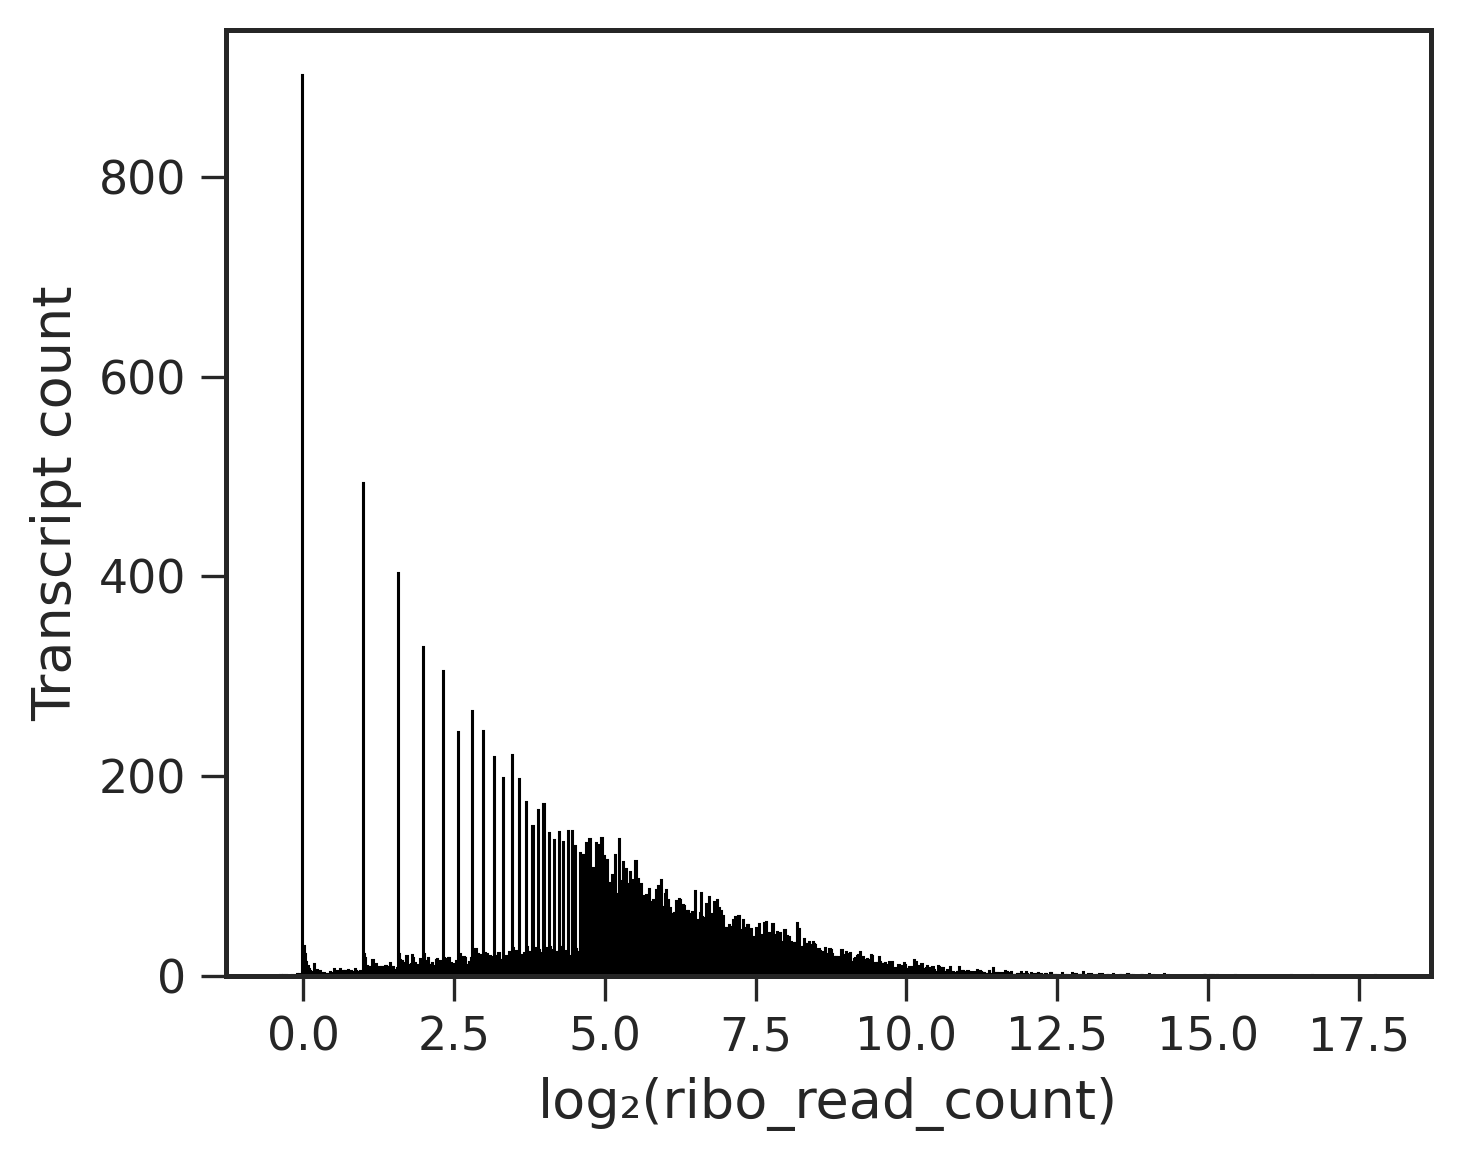

In [131]:
# ============================================
# Histogram
# ============================================

metric = "ribo_read_count"
log = True

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 5, h=4)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

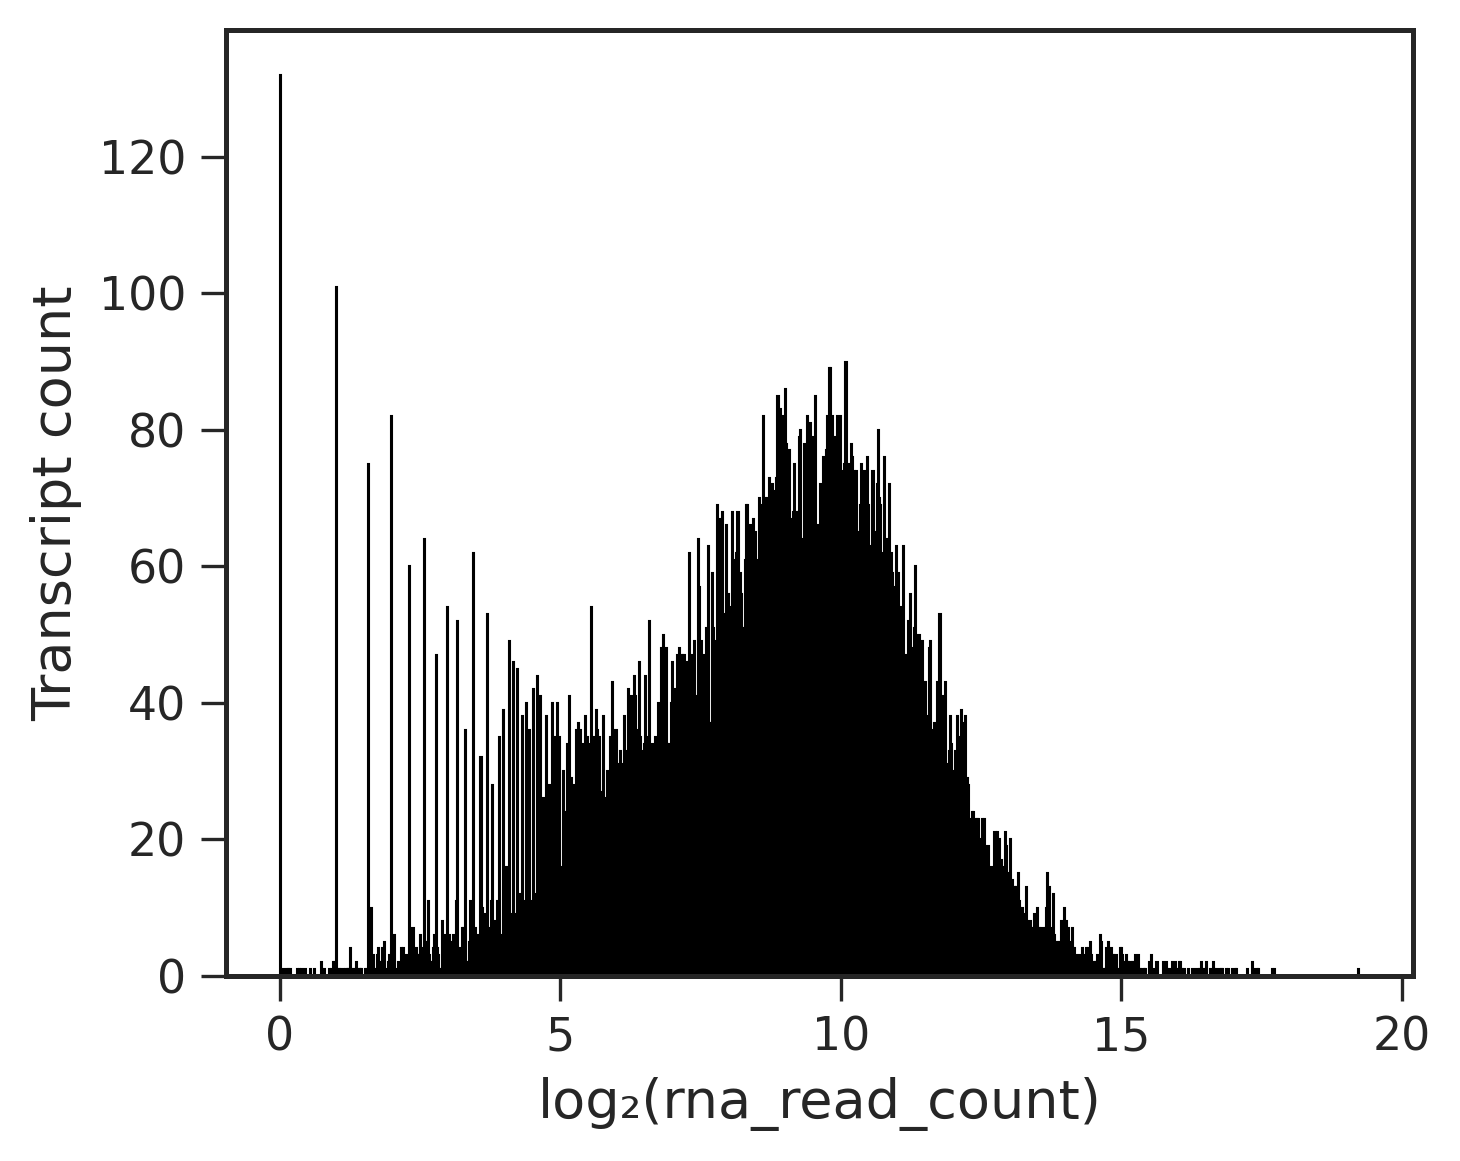

In [132]:
# ============================================
# Histogram
# ============================================

metric = "rna_read_count"
log = True

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 5, h=4)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

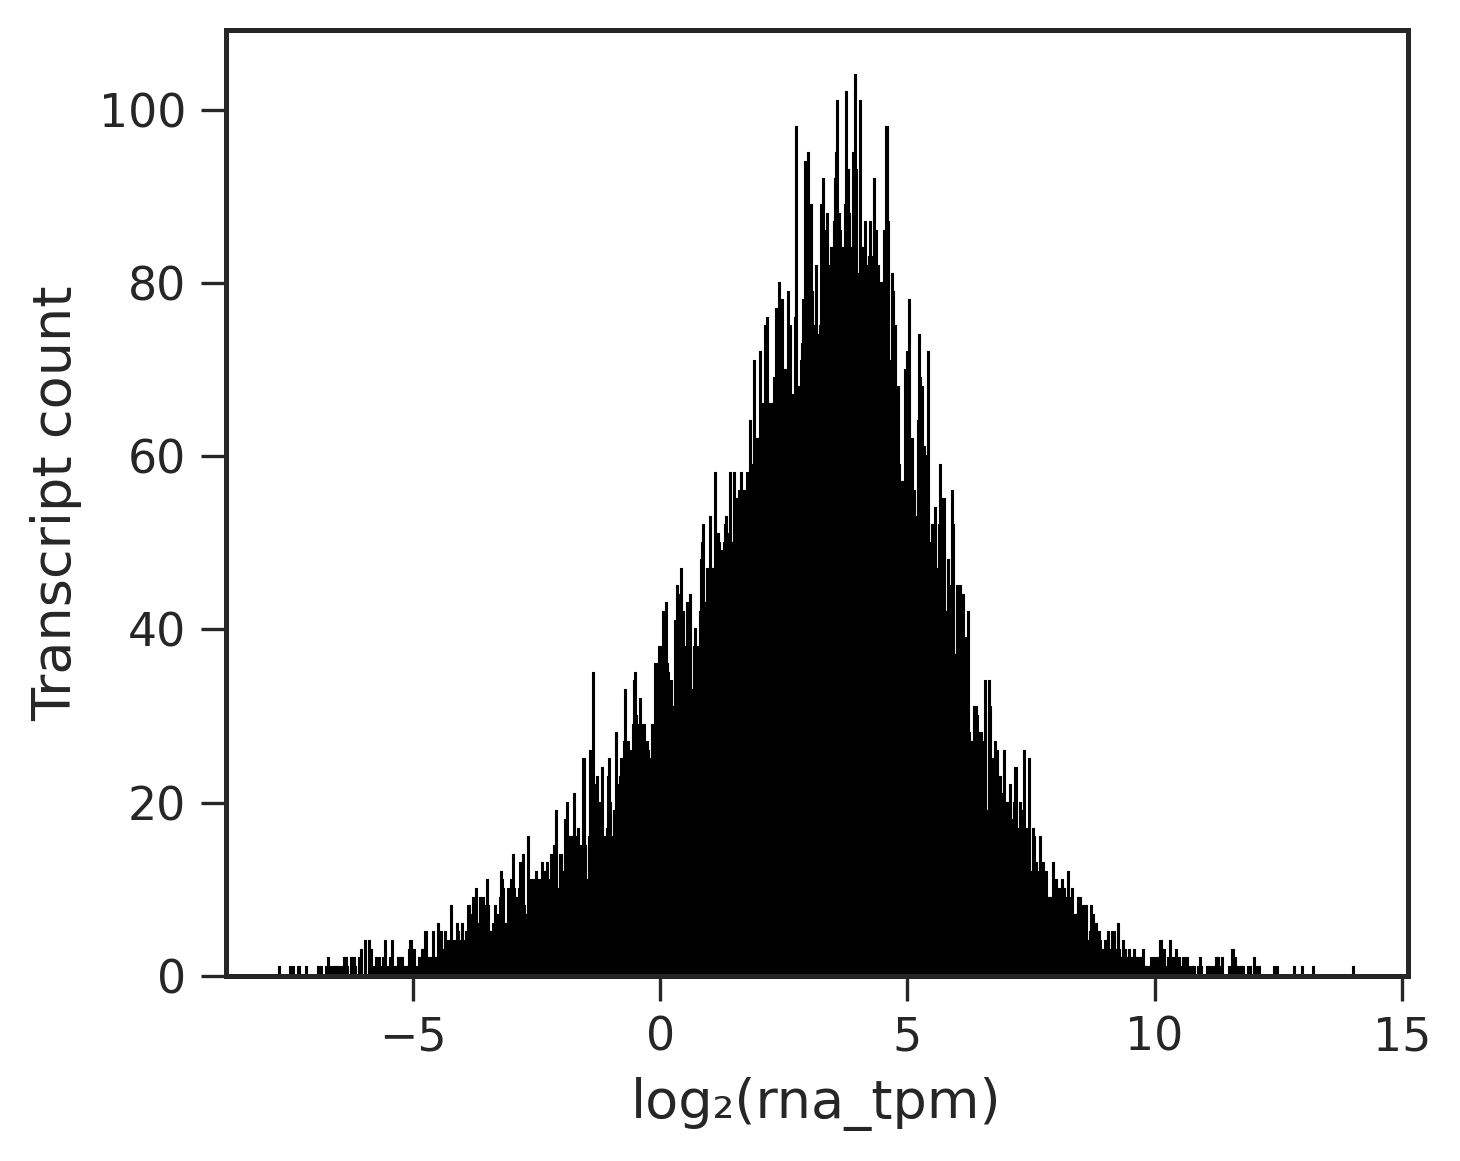

In [133]:
# ============================================
# Histogram
# ============================================

metric = "rna_tpm"
log = True

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 5, h=4)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

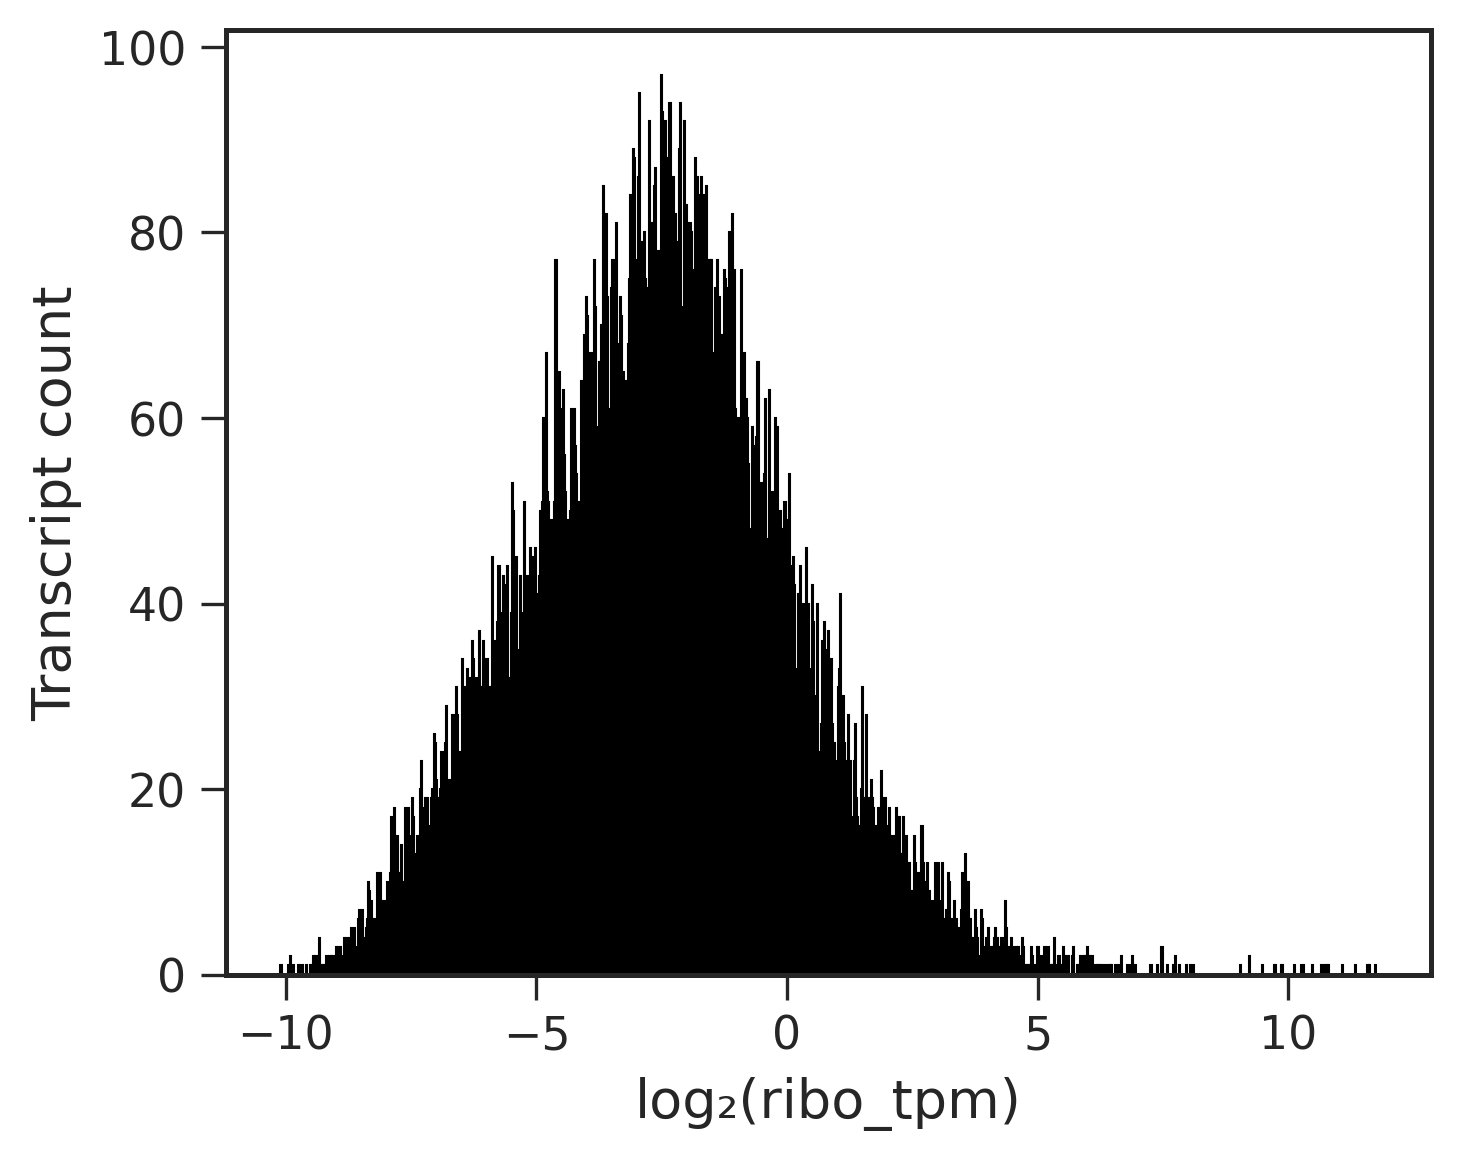

In [134]:
# ============================================
# Histogram
# ============================================

metric = "ribo_tpm"
log = True

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 5, h=4)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

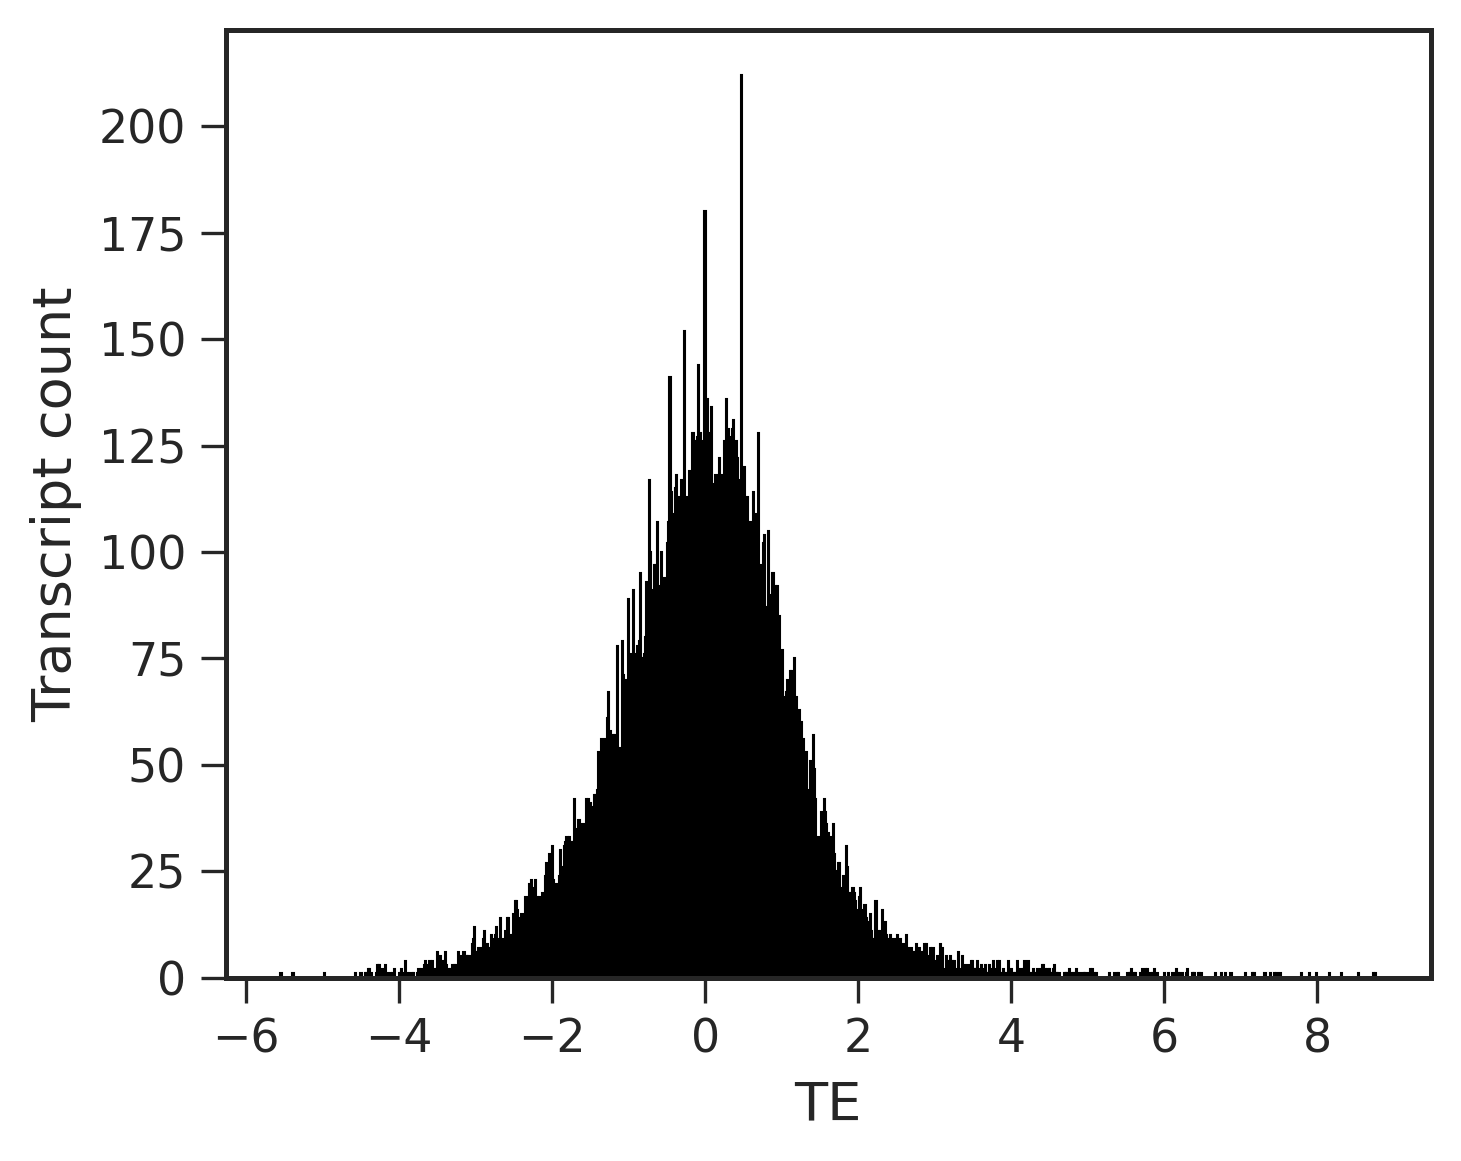

In [135]:
# ============================================
# Histogram
# ============================================

metric = "TE"
log = False

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 5, h=4)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()

In [138]:
MIN_READ_COUNT = 50

master = master.loc[
    (master["rna_read_count"] > MIN_READ_COUNT) &
    (master["ribo_read_count"] > MIN_READ_COUNT)
].copy()

print(master.shape)
display(master.head())
display(master.describe())

(9496, 10)


,transcript_id,gene_id,gene_name,ribo_read_count,rna_read_count,ribo_tpm,rna_tpm,rna_clr,ribo_clr,TE
15,AT1G01050.1,AT1G01050,AT1G01050,197.020,2517.218,1.709312,89.148807,1.844027,1.715201,0.470685
31,AT1G01080.2,AT1G01080,AT1G01080,347.337,1958.910,2.091418,48.149006,1.593260,2.282191,1.206915
32,AT1G01090.1,AT1G01090,AT1G01090,1310.000,6066.000,5.137187,97.104710,2.723572,3.609678,1.771566
33,AT1G01100.2,AT1G01100,AT1G01100,245.334,3703.700,2.837962,174.891728,2.230205,1.934516,0.429373
34,AT1G01100.1,AT1G01100,AT1G01100,144.906,55.449,2.775500,4.335418,-1.971419,1.407981,2.738473


,ribo_read_count,rna_read_count,ribo_tpm,rna_tpm,rna_clr,ribo_clr,TE
count,9496.000000,9496.000000,9496.000000,9496.000000,9496.000000,9496.000000,9496.000000
mean,416.931924,3384.309885,2.662572,78.470734,1.326710,1.585271,0.689888
std,3009.631233,10757.995010,28.695833,320.526352,1.180483,0.983672,0.842510
min,50.013000,50.015000,0.045377,0.342367,-2.074560,0.344179,-2.450420
25%,81.093750,745.000000,0.327084,12.091965,0.626501,0.827502,0.166943
50%,138.032000,1495.000000,0.628211,25.633226,1.322998,1.359381,0.612052
75%,290.682500,3046.357250,1.450090,58.970269,2.034819,2.104127,1.118527
max,226223.884000,623074.409000,2188.258548,16752.574621,7.355538,8.761176,8.740421


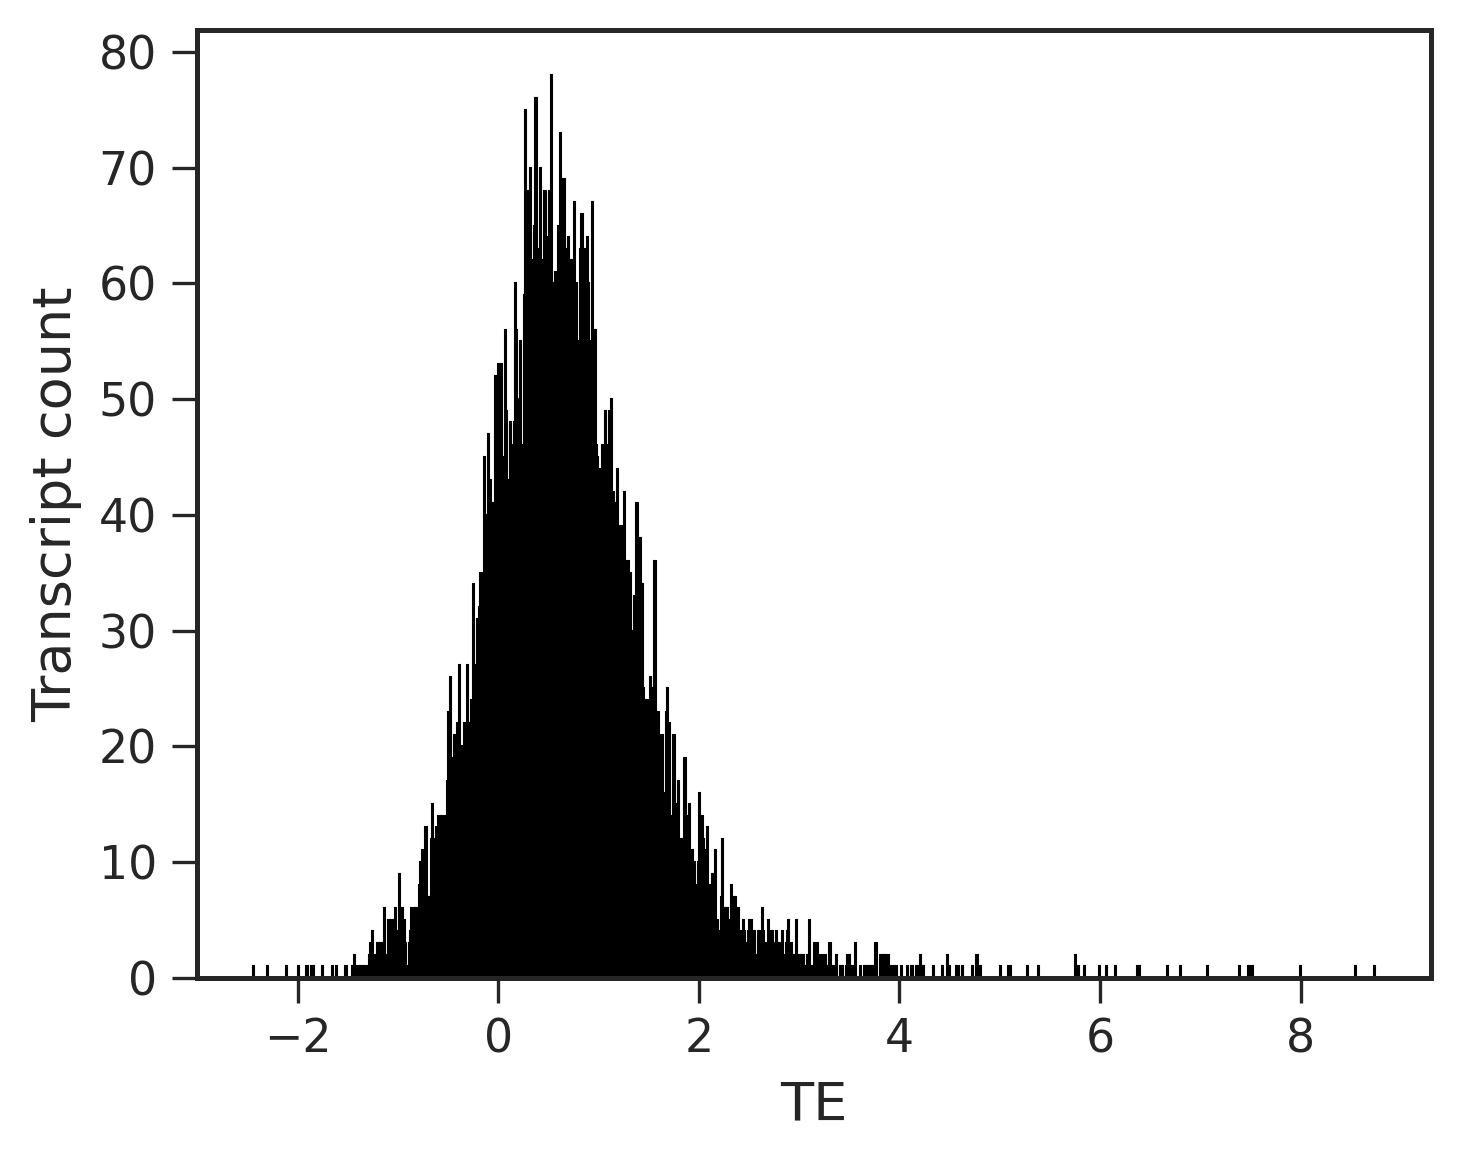

In [137]:
# ============================================
# Histogram
# ============================================

metric = "TE"
log = False

values = master[metric].copy()

if log:
    values = np.log2(values)

fig, ax = make_fig(w = 5, h=4)

ax.hist(
    values,
    bins=1000,
    edgecolor="black",
    linewidth=0.5,
)

xlabel = f"log₂({metric})" if log else metric

ax.set_xlabel(xlabel)
ax.set_ylabel("Transcript count")

plt.tight_layout()
plt.show()